Merged Dataset Shape: (18637, 7)
Cleaning text data...
Vectorizing text...
Reducing dimensionality...
Running K-Means clustering...


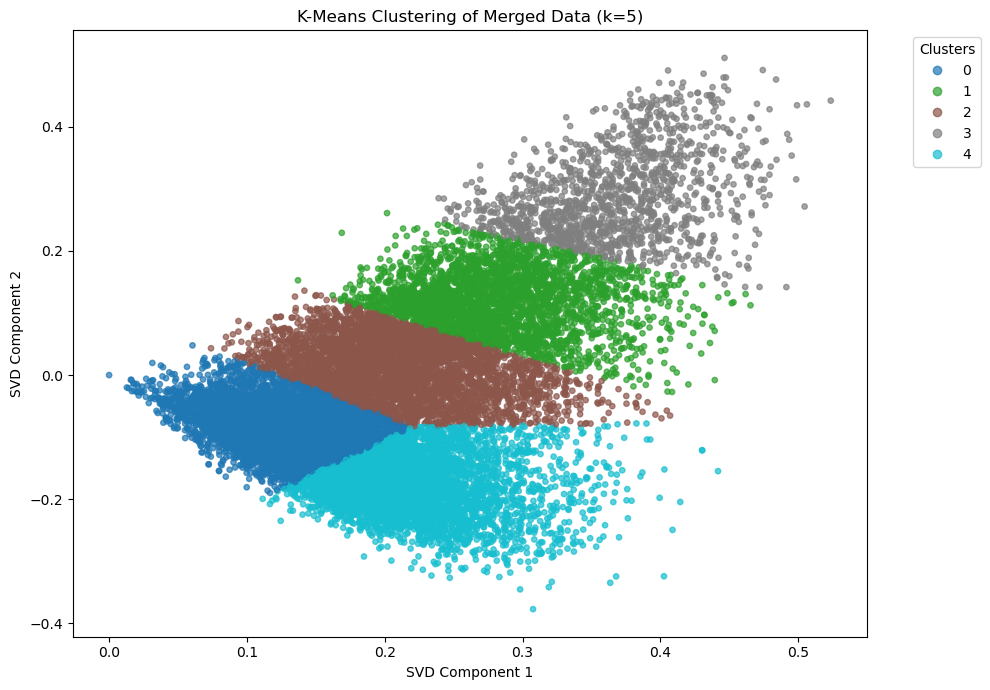


Games per K-Means archetype:
kmeans_label
0    5322
1    2970
2    4118
3    1360
4    4867
Name: count, dtype: int64


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
import html
import re
import os

# 1. Load the datasets
train_file = "../../data/to_train.csv"
predict_file = "../../data/to_predict.csv"

if os.path.exists(train_file) and os.path.exists(predict_file):
    df_train = pd.read_csv(train_file)
    df_predict = pd.read_csv(predict_file)
    
    # Add a tracker column to identify the source of each row
    df_train['source'] = 'train'
    df_predict['source'] = 'predict'
    
    # Merge the datasets
    df_merged = pd.concat([df_train, df_predict], ignore_index=True)
    print(f"Merged Dataset Shape: {df_merged.shape}")
else:
    raise FileNotFoundError("Make sure both 'to_train.csv' and 'to_predict.csv' are in the directory.")

# 2. Clean the text data
text_column = 'description'
df_merged = df_merged.dropna(subset=[text_column])

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', '', text) # Remove HTML tags
    text = re.sub(r'[\r\n]+', ' ', text) # Remove newlines
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text) # Remove special characters
    return text.lower()

print("Cleaning text data...")
df_merged['clean_text'] = df_merged[text_column].apply(clean_text)

# 3. Text Vectorization (TF-IDF)
print("Vectorizing text...")
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
X_tfidf = tfidf.fit_transform(df_merged['clean_text'])

# 4. Dimensionality Reduction (SVD down to 2 components)
print("Reducing dimensionality...")
svd = TruncatedSVD(n_components=2, random_state=42)
X_reduced = svd.fit_transform(X_tfidf)

# 5. Fit K-Means Clustering
# Using 5 clusters as outlined in the project plan
print("Running K-Means clustering...")
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
df_merged['kmeans_label'] = kmeans.fit_predict(X_reduced)

# 6. Visualization
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=df_merged['kmeans_label'], cmap='tab10', s=15, alpha=0.7)

plt.title('K-Means Clustering of Merged Data (k=5)')
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.legend(*scatter.legend_elements(), title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 7. Display the distribution
print("\nGames per K-Means archetype:")
print(df_merged['kmeans_label'].value_counts().sort_index())

# Optional: Save the merged dataframe with cluster labels for further analysis
# df_merged.to_csv("clustered_games.csv", index=False)